# Active Lives 2020-21 — London EDA & Multi-Pillar Analysis (Wave 6, COVID year)

Same template as the other wave notebooks, configured to what the diagnostics proved.
**2020-21 covers mid-Nov 2020 to mid-Nov 2021 — a full year of Covid-19 restrictions.**

**Verified for 2020-21:**

| Item | 2020-21 |
|---|---|
| Rows | 16,028 × 589 |
| Geography | `LA_2021`, **wave-specific map from this wave's own `.sav`** |
| Borough codes | **4 swapped vs shared map** (8⇉9 Barnet/Barking, 138⇉139 K&C/Islington) |
| Ethnicity | **`Asian (excl. Chinese)`** — matches baseline, *not* "South Asian" |
| Activity | middle band **"Fairly Active"** — matches baseline |
| NS-SEC | **4 codes** — matches baseline (no 5th code) |
| Health | present → secondary model only |
| Volunteering | **75.5% non-null** — best coverage of any wave |
| Indoor/Outdoor | **38.0% rotation subgroup** |

> **This wave uses the 2022-23 baseline codebook essentially as-is** — unlike 2017-18 / 2018-19,
> which needed the "South Asian" label and a 5-code NS-SEC. Do not pattern-match from those waves.

> **Benchmark — the pre-COVID band does NOT apply.** Sport England reported **61.4% active in
> England** for Nov 2020-21 (down from ~62-63% pre-pandemic). London runs ~1-2pp above England, so
> **expect roughly 62-64%**. A figure in that range reflects the real pandemic dip and is *correct*,
> not a pipeline error.


## 1. Load the pre-filtered London CSV

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV      = r"C:/Users/Lenovo/London-Sport-Forecasting-Patterns/data/processed/active_lives_london_y6_2020-21.csv"
SAV_2020 = r"C:\Users\Lenovo\London-Sport-Forecasting-Patterns\data\raw\active_lives_survey_nov_20-21_data_year_6_shared_20250103 (1).sav"

df = pd.read_csv(CSV)
print("shape:", df.shape, "| year:", df["survey_year"].unique() if "survey_year" in df else "?")

shape: (16028, 589) | year: ['2020-21']


## 2. Codebook — decode numeric codes to labels

Verified via `compare_codebooks`: this wave matches the **2022-23 baseline** on ethnicity
(`Asian (excl. Chinese)`), activity band (`Fairly Active`), and NS-SEC (4 codes) — unlike
2017-18 / 2018-19. Only wave-specific item: **`VolAny` is 0/1**, decoded so the `"Volunteered"`
target matches every other wave. `health` is decoded here too (2018-19 left it as raw codes).

In [5]:
CODEBOOK = {
    "MEMS7GR_SPORTCOUNT_A01":     {0: "Inactive", 1: "Fairly Active", 2: "Active"},
    "MEMS7GR_IN_SPORTCOUNT_A01":  {0: "Inactive", 1: "Fairly Active", 2: "Active"},
    "MEMS7GR_OUT_SPORTCOUNT_A01": {0: "Inactive", 1: "Fairly Active", 2: "Active"},
    "Gend3":  {1: "Male", 2: "Female", 3: "Other"},
    "Eth7":   {1: "White British", 2: "White Other", 3: "Asian (excl. Chinese)",   # <-- BASELINE label
               4: "Black", 5: "Chinese", 6: "Mixed", 7: "Other ethnic group"},
    "Disab3": {1: "Limiting disability", 2: "Non-limiting disability", 3: "No disability"},
    "Age9":   {1: "14-15", 2: "16-24", 3: "25-34", 4: "35-44", 5: "45-54",
               6: "55-64", 7: "65-74", 8: "75-84", 9: "85+"},
    "NSSEC5": {1: "Higher social groups (NS-SEC 1-2)", 2: "Middle social groups (NS-SEC 3-5)",
               3: "Lower social groups (NS-SEC 6-8)",  4: "Students and other/unclassified"},
               # 4 codes only -- no 5th code in this wave (matches baseline)
    "Educ6":  {1: "Level 4 or above", 2: "Level 3 and equivalents", 3: "Level 2 and equivalents",
               4: "Level 1 and below", 5: "Another type of qualification", 6: "No qualifications"},
    "BMIG":   {1: "Underweight", 2: "Healthy weight", 3: "Overweight", 4: "Obese"},
    "VolAny": {0: "Not volunteered", 1: "Volunteered"},                      # <-- 0/1 in this wave
    "health": {1: "Very good", 2: "Good", 3: "Fair", 4: "Bad", 5: "Very bad"},   # confirm wording vs .sav
}

VOL_ROLES = {f"volint{i}_vol": f"role {i}" for i in range(1, 8)}
print("codebook entries:", len(CODEBOOK))

codebook entries: 12


## 3. Borough map — derived from **this wave's own `.sav`**, then proven

The shared `LONDON_LA2021` is **not** used: 4 of this wave's codes mean different boroughs.
We derive the map from `LA_2021`'s own GSS-bearing labels, verify it, print the swaps for the
record, and confirm all four vintage columns agree on GSS.

In [6]:
import pyreadstat

def build_london_map_from_sav(sav_path, la_col):
    """Derive {int_code: (gss, name)} from a wave's OWN .sav value labels."""
    _, meta = pyreadstat.read_sav(sav_path, metadataonly=True)
    labels = meta.variable_value_labels.get(la_col, {})
    m = {}
    for cd, lbl in labels.items():
        s = str(lbl)
        if s.startswith("E09"):
            gss = s.split()[0]
            m[int(cd)] = (gss, s[len(gss):].strip())
    return m

def verify_borough_mapping(sav_path, la_col, london_map):
    """Prove each integer -> GSS from the wave's own labels."""
    _, meta = pyreadstat.read_sav(sav_path, metadataonly=True)
    labels = meta.variable_value_labels.get(la_col, {})
    mism = [f"code {c}: map says {g} {n}  |  .sav says {labels.get(c)!r}"
            for c, (g, n) in london_map.items()
            if labels.get(c) is not None and g not in str(labels.get(c))]
    print("=== verify ->", "PROVEN OK" if not mism else f"{len(mism)} MISMATCH", "===")
    for x in mism:
        print("  -", x)
    return not mism

LA_COL = "LA_2021"
LONDON_MAP = build_london_map_from_sav(SAV_2020, LA_COL)
print(f"{LA_COL}: {len(LONDON_MAP)} London codes derived from this wave's .sav")
verify_borough_mapping(SAV_2020, LA_COL, LONDON_MAP)

# Divergence from the shared map (what a coverage check would MISS)
from active_lives_utils import LONDON_LA2021 as SHARED
swaps = [f"code {c}: shared={SHARED[c][0]} {SHARED[c][1]}  |  2020-21={g} {n}"
         for c, (g, n) in LONDON_MAP.items() if c in SHARED and SHARED[c][0] != g]
print("\n=== vs shared map ->", "SAME NUMBERING" if not swaps else f"{len(swaps)} SWAPPED CODE(S)", "===")
for s in swaps:
    print("  -", s)

# All vintage columns must resolve to the SAME GSS per respondent
vint = ["LA_2015", "LA_2019", "LA_2021", "LA_2023"]   # this wave carries LA_2019
maps = {la: build_london_map_from_sav(SAV_2020, la) for la in vint}
gsscheck = pd.DataFrame({la: df[la].map({k: v[0] for k, v in m.items()}) for la, m in maps.items()})
print("\nall vintages agree on GSS for every respondent:", gsscheck.nunique(axis=1).eq(1).all())

LA_2021: 33 London codes derived from this wave's .sav
=== verify -> PROVEN OK ===

=== vs shared map -> 4 SWAPPED CODE(S) ===
  - code 8: shared=E09000003 Barnet  |  2020-21=E09000002 Barking and Dagenham
  - code 9: shared=E09000002 Barking and Dagenham  |  2020-21=E09000003 Barnet
  - code 138: shared=E09000020 Kensington and Chelsea  |  2020-21=E09000019 Islington
  - code 139: shared=E09000019 Islington  |  2020-21=E09000020 Kensington and Chelsea

all vintages agree on GSS for every respondent: True


## 4. Configure, decode, and build the London analysis frame

In [7]:
CONFIG = {
    "weight": "wt_final", "la_code": LA_COL,
    "activity_band": "MEMS7GR_SPORTCOUNT_A01",
    "activity_in":   "MEMS7GR_IN_SPORTCOUNT_A01",
    "activity_out":  "MEMS7GR_OUT_SPORTCOUNT_A01",
    "age": "Age9", "gender": "Gend3", "ethnicity": "Eth7", "disability": "Disab3",
    "nssec": "NSSEC5", "education": "Educ6", "bmi": "BMIG",
    "health": "health",          # <-- PRESENT in this wave
    "volunteer": "VolAny",
}

def decode(df, config, codebook):
    out = df.copy()
    for concept, var in config.items():
        if var in codebook:
            out[concept] = out[var].map(codebook[var])
        elif var in out.columns:
            out[concept] = out[var]
    out["weight"] = pd.to_numeric(out[config["weight"]], errors="coerce")
    return out

# Exclude 14-15 (out of scope for the adult survey)
df = df[df["Age9"] != 1.0].copy()
data = decode(df, CONFIG, CODEBOOK)

# Apply THIS WAVE'S map, restrict to the 32 boroughs (exclude City of London)
data["gss"]     = data[LA_COL].map({k: v[0] for k, v in LONDON_MAP.items()})
data["LA_name"] = data[LA_COL].map({k: v[1] for k, v in LONDON_MAP.items()})
london = data[data["gss"].notna() & (data["gss"] != "E09000001")].copy()

print("borough coverage (this wave's map):", data["gss"].notna().mean())
assert london["LA_name"].nunique() == 32, f"Expected 32 boroughs, got {london['LA_name'].nunique()}"
print(f"London analysis frame: {len(london):,} rows, {london['LA_name'].nunique()} boroughs")

# Sanity anchor on the two boroughs the swap would have transposed
print("\nBarnet n =", (london["LA_name"] == "Barnet").sum(),
      "| Barking and Dagenham n =", (london["LA_name"] == "Barking and Dagenham").sum())

borough coverage (this wave's map): 1.0
London analysis frame: 16,028 rows, 32 boroughs

Barnet n = 512 | Barking and Dagenham n = 516


## 5. Weighted summary helpers

In [8]:
def weighted_share(df, group_cols, target_col, target_value):
    """NOTE: the returned `n` is the count of respondents who ANSWERED target_col
    (post-dropna), i.e. the base size -- not the number in the target category."""
    d = df.dropna(subset=["weight", target_col]).copy()
    d["_num"] = (d[target_col] == target_value).astype(float) * d["weight"]
    if group_cols:
        g = d.groupby(group_cols, dropna=False)
        out = (g["_num"].sum() / g["weight"].sum()).rename("weighted_share").reset_index()
        out["n"] = g.size().values
        return out
    return d["_num"].sum() / d["weight"].sum()

def weighted_distribution(df, group_col, target_col="activity_band"):
    d = df.dropna(subset=["weight", target_col, group_col]).copy()
    tab = d.groupby([group_col, target_col])["weight"].sum().unstack(fill_value=0)
    return tab.div(tab.sum(axis=1), axis=0)

## 6. EDA — missingness map

Ordinary item non-response (a few %) vs **structural** missingness on rotation modules
(indoor/outdoor ~65%, volunteering ~37%). Structural missingness is by design — it means those
pillars run on a smaller, indicative base, not that the data is faulty.

activity_in      0.620
activity_out     0.620
volunteer        0.245
bmi              0.193
nssec            0.075
disability       0.067
ethnicity        0.064
education        0.034
health           0.018
age              0.008
gender           0.002
activity_band    0.000
weight           0.000


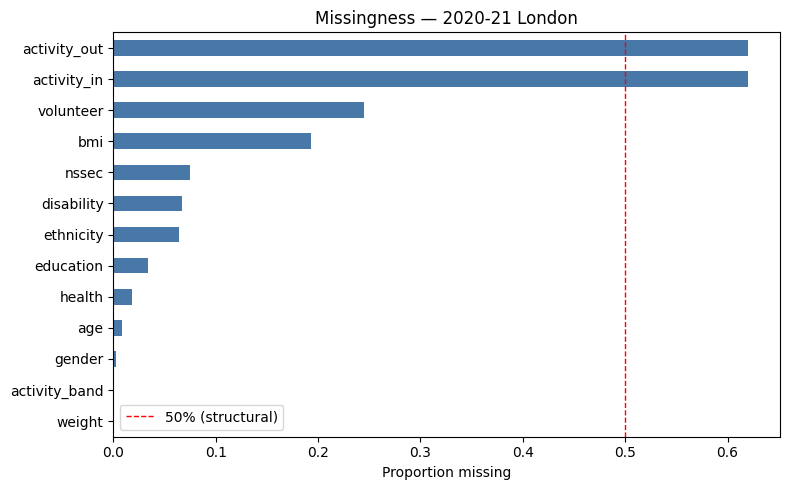

In [9]:
concept_cols = ["activity_band","activity_in","activity_out","age","gender","ethnicity",
                "disability","nssec","education","health","bmi","volunteer","weight"]
miss = london[concept_cols].isna().mean().sort_values(ascending=False)
print(miss.round(3).to_string())

fig, ax = plt.subplots(figsize=(8,5))
miss.sort_values().plot(kind="barh", ax=ax, color="#4878a8")
ax.axvline(0.5, color="red", ls="--", lw=1, label="50% (structural)")
ax.set_xlabel("Proportion missing"); ax.set_title("Missingness — 2020-21 London")
ax.legend(); plt.tight_layout(); plt.show()

In [10]:
def check_routing(df, gate_col, gate_value, dependent_cols, label=""):
    """Among rows where gate_col==gate_value, how complete are the dependents?
    ~0% missing = clean universal routing; high+uniform = rotation subsample."""
    cols = [c for c in dependent_cols if c in df.columns]
    if not cols:
        print(f"{label or gate_col}: no dependent columns present"); return
    sub = df[df[gate_col] == gate_value]
    m = sub[cols].isna().mean().round(3)
    all_blank = sub[cols].isna().all(axis=1).sum()
    print(f"{label or gate_col}=={gate_value!r} (n={len(sub)}): "
          f"max dep-missing={m.max():.3f}, all-blank={all_blank} ({all_blank/max(len(sub),1):.1%})")

role_cols = [c for c in london.columns if c.startswith("volint")]
check_routing(london, "volunteer", "Volunteered", role_cols, "Volunteer -> role detail")
disty = [c for c in london.columns if c.startswith("disty")]
check_routing(london, "disability", "Limiting disability", disty, "Limiting disability -> impairment types")

Volunteer -> role detail=='Volunteered' (n=1454): max dep-missing=0.000, all-blank=0 (0.0%)
Limiting disability -> impairment types=='Limiting disability' (n=2259): max dep-missing=0.023, all-blank=51 (2.3%)


## 7. EDA — weight validity & sample composition

Weight: min=0.1714 max=18.43 non-positive=0 missing=0


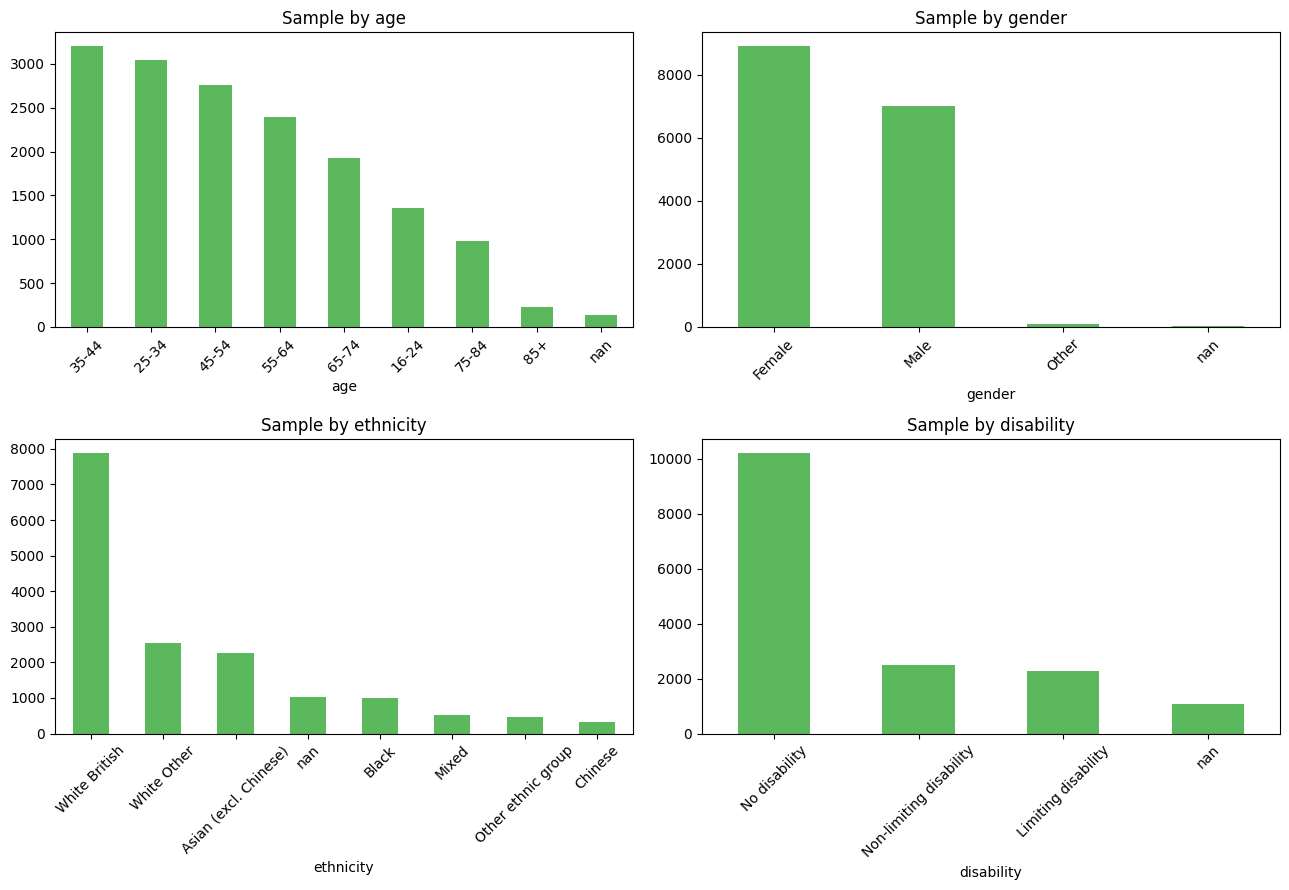

In [11]:
w = london["weight"]
print("Weight: min={:.4f} max={:.2f} non-positive={} missing={}".format(
    w.min(), w.max(), int((w<=0).sum()), int(w.isna().sum())))

fig, axes = plt.subplots(2,2, figsize=(13,9))
for ax, c in zip(axes.ravel(), ["age","gender","ethnicity","disability"]):
    london[c].value_counts(dropna=False).plot(kind="bar", ax=ax, color="#5cb85c")
    ax.set_title(f"Sample by {c}"); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 8. Pillar 1 — Participation / activity levels
Overall, by demographic, and by borough. Benchmarks: 2015-16 London 63.5%, 2017-18 London 64.6%.

In [12]:
overall = weighted_share(london, [], "activity_band", "Active")
print(f"Overall London % Active (2020-21): {overall:.3f}")
print("  benchmark: England Nov 2020-21 = 0.614 (Sport England); London ~1-2pp above -> expect ~0.62-0.64")
print("  pre-COVID London: 2018-19 = 0.645 | 2017-18 = 0.646")
for factor in ["age","gender","ethnicity","disability","nssec","education","health","bmi"]:
    print(f"\n=== % Active by {factor} ===")
    print(weighted_share(london, [factor], "activity_band", "Active").dropna(subset=[factor]).to_string(index=False))

Overall London % Active (2020-21): 0.624
  benchmark: England Nov 2020-21 = 0.614 (Sport England); London ~1-2pp above -> expect ~0.62-0.64
  pre-COVID London: 2018-19 = 0.645 | 2017-18 = 0.646

=== % Active by age ===
  age  weighted_share    n
16-24        0.649802 1362
25-34        0.684692 3044
35-44        0.636052 3201
45-54        0.622362 2758
55-64        0.610414 2400
65-74        0.601573 1928
75-84        0.449308  978
  85+        0.216991  223

=== % Active by gender ===
gender  weighted_share    n
Female        0.608223 8896
  Male        0.641937 7013
 Other        0.561461   82

=== % Active by ethnicity ===
            ethnicity  weighted_share    n
Asian (excl. Chinese)        0.531795 2271
                Black        0.529500 1003
              Chinese        0.599714  323
                Mixed        0.702092  521
   Other ethnic group        0.543857  467
        White British        0.675946 7884
          White Other        0.686376 2535

=== % Active by disabi

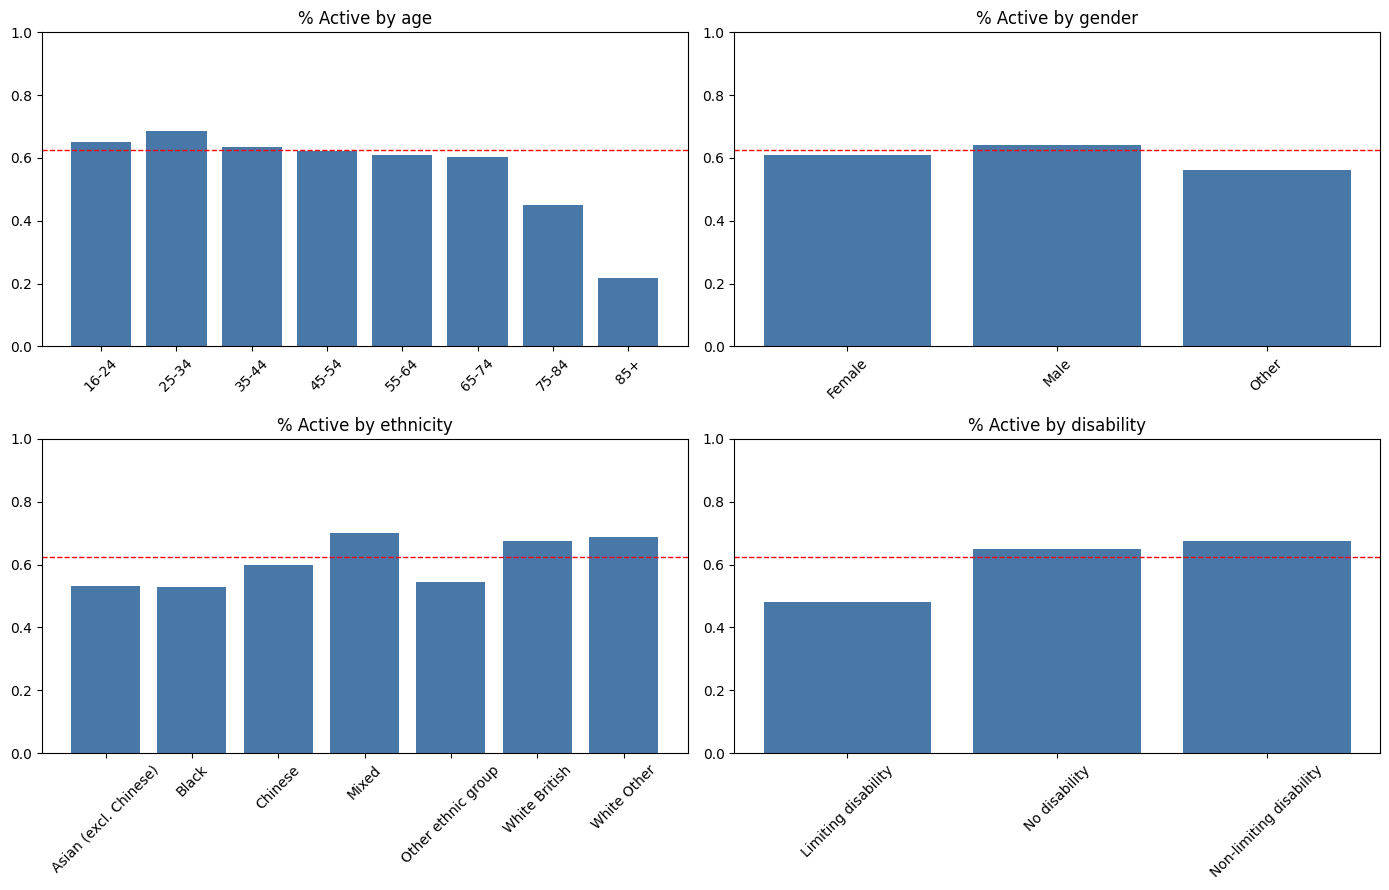

In [13]:
factors = ["age","gender","ethnicity","disability"]
fig, axes = plt.subplots(2,2, figsize=(14,9))
for ax, factor in zip(axes.ravel(), factors):
    res = weighted_share(london, [factor], "activity_band", "Active").dropna(subset=[factor])
    ax.bar(res[factor].astype(str), res["weighted_share"], color="#4878a8")
    ax.axhline(overall, color="red", ls="--", lw=1); ax.set_ylim(0,1)
    ax.set_title(f"% Active by {factor}"); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

### Pillar 1 — by borough

               LA_name  weighted_share   n
  Barking and Dagenham        0.503147 516
             Redbridge        0.527664 509
              Havering        0.534209 475
              Hounslow        0.537050 538
                 Brent        0.541213 507
            Hillingdon        0.542003 490
                Bexley        0.544922 497
                Newham        0.560201 503
                Sutton        0.572406 532
               Croydon        0.576843 503
        Waltham Forest        0.578258 505
                Harrow        0.584780 496
               Enfield        0.587065 488
                Ealing        0.588256 508
         Tower Hamlets        0.590602 486
                Barnet        0.626378 512
           Westminster        0.634702 491
              Haringey        0.646575 485
             Greenwich        0.655341 495
                Merton        0.663622 491
  Kingston upon Thames        0.664584 478
Kensington and Chelsea        0.667788 502
           

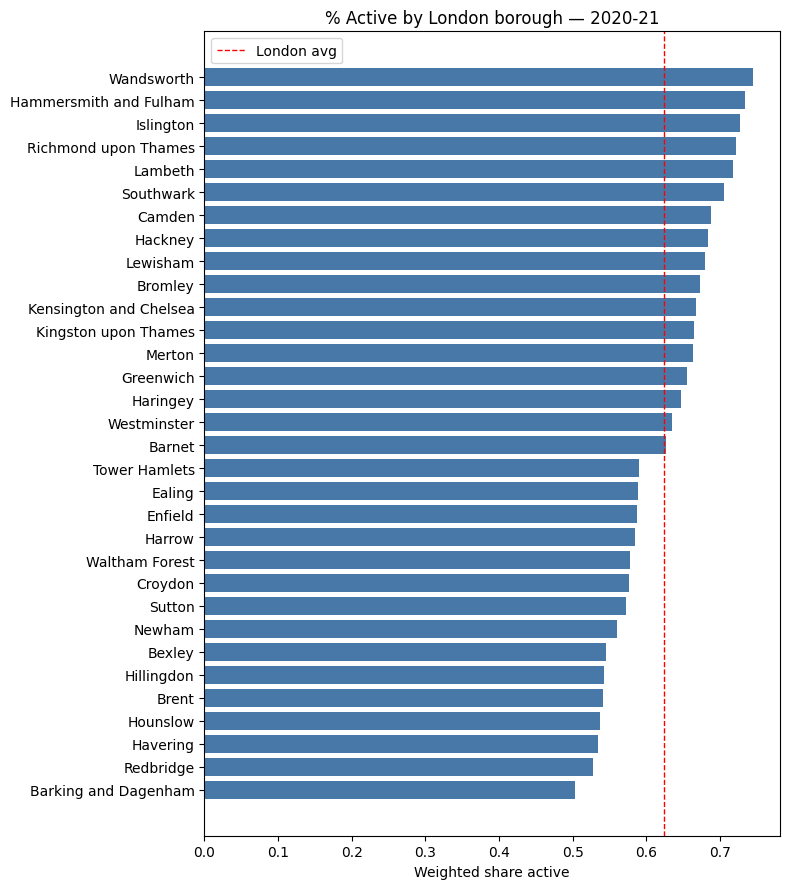

In [14]:
bor = weighted_share(london, ["LA_name"], "activity_band", "Active").sort_values("weighted_share")
print(bor.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,9))
ax.barh(bor["LA_name"], bor["weighted_share"], color="#4878a8")
ax.axvline(overall, color="red", ls="--", lw=1, label="London avg")
ax.set_xlabel("Weighted share active"); ax.set_title("% Active by London borough — 2020-21")
ax.legend(); plt.tight_layout(); plt.show()

## 9. Pillar 2 — Demographics: relationships between variables
Cramér's V (0 = independent, 1 = perfectly associated). `health` is present this wave, so it is
included — matching the 2022-23 model.

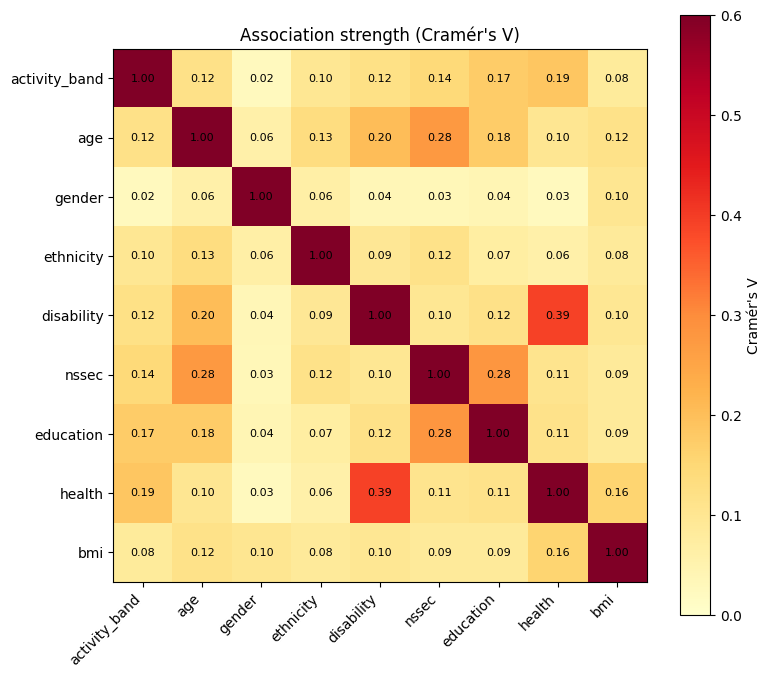

In [15]:
from itertools import combinations
from scipy.stats import chi2_contingency
assoc = ["activity_band","age","gender","ethnicity","disability","nssec","education","health","bmi"]

def cramers_v(a, b, df):
    t = pd.crosstab(df[a], df[b])
    if t.shape[0] < 2 or t.shape[1] < 2: return np.nan
    chi2 = chi2_contingency(t)[0]; n = t.values.sum(); r, k = t.shape
    return np.sqrt((chi2/n) / (min(r-1, k-1)))

M = pd.DataFrame(np.eye(len(assoc)), index=assoc, columns=assoc)
for a, b in combinations(assoc, 2):
    v = cramers_v(a, b, london); M.loc[a,b] = M.loc[b,a] = v

fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(M.values, cmap="YlOrRd", vmin=0, vmax=0.6)
ax.set_xticks(range(len(assoc))); ax.set_xticklabels(assoc, rotation=45, ha="right")
ax.set_yticks(range(len(assoc))); ax.set_yticklabels(assoc)
for i in range(len(assoc)):
    for j in range(len(assoc)):
        ax.text(j, i, f"{M.values[i,j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Association strength (Cramér's V)")
fig.colorbar(im, label="Cramér's V"); plt.tight_layout(); plt.show()

## 10. Pillar 3 — Indoor vs Outdoor
Rotation-subgroup questions — only **34.5%** of respondents were asked. Indicative, not headline.

Indoor/outdoor base: 6,087 of 16,028 (38.0%)
Indoor: weighted % active = 0.192
Outdoor: weighted % active = 0.548

% Active indoor vs outdoor by ethnicity:
place                  Indoor  Outdoor
ethnicity                             
Asian (excl. Chinese)   0.128    0.412
Black                   0.221    0.411
Chinese                 0.232    0.497
Mixed                   0.242    0.603
Other ethnic group      0.133    0.483
White British           0.205    0.631
White Other             0.235    0.620


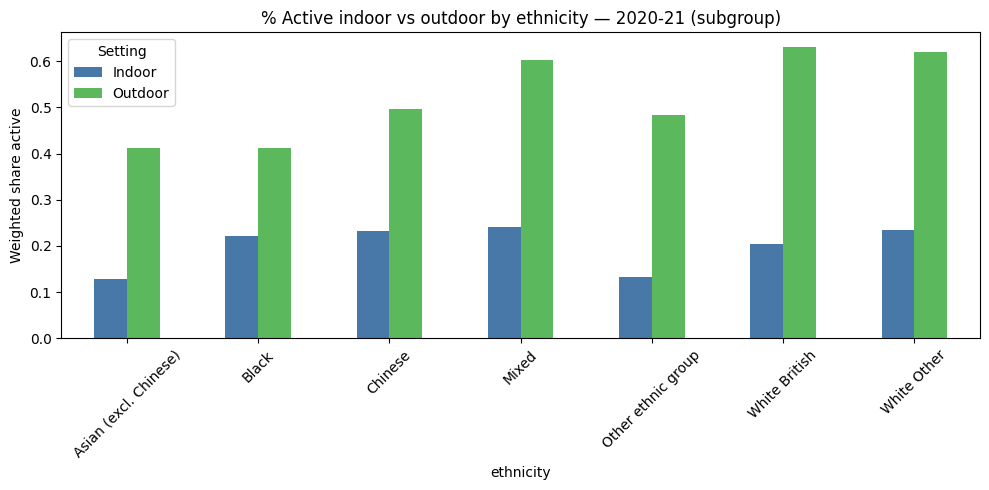

In [16]:
io = london.dropna(subset=["activity_in","activity_out","weight"]).copy()
print(f"Indoor/outdoor base: {len(io):,} of {len(london):,} ({len(io)/len(london):.1%})")
for place, col in [("Indoor","activity_in"), ("Outdoor","activity_out")]:
    print(f"{place}: weighted % active = {weighted_share(io, [], col, 'Active'):.3f}")

rows = []
for col, place in [("activity_in","Indoor"), ("activity_out","Outdoor")]:
    r = weighted_share(io, ["ethnicity"], col, "Active").dropna(subset=["ethnicity"]); r["place"] = place; rows.append(r)
pivot = pd.concat(rows).pivot(index="ethnicity", columns="place", values="weighted_share")
print("\n% Active indoor vs outdoor by ethnicity:"); print(pivot.round(3).to_string())
pivot.plot(kind="bar", figsize=(10,5), color=["#4878a8","#5cb85c"])
plt.title("% Active indoor vs outdoor by ethnicity — 2020-21 (subgroup)")
plt.ylabel("Weighted share active"); plt.xticks(rotation=45); plt.legend(title="Setting")
plt.tight_layout(); plt.show()

### Pillar 3 — indoor vs outdoor by borough (subgroup — small n, indicative)

In [17]:
rows = []
for col, place in [("activity_in","Indoor"), ("activity_out","Outdoor")]:
    r = weighted_share(io, ["LA_name"], col, "Active").dropna(subset=["LA_name"]); r["place"] = place; rows.append(r)
bor_io = pd.concat(rows).pivot(index="LA_name", columns="place", values="weighted_share")
print(bor_io.round(3).to_string())

place                   Indoor  Outdoor
LA_name                                
Barking and Dagenham     0.103    0.418
Barnet                   0.190    0.575
Bexley                   0.171    0.405
Brent                    0.135    0.418
Bromley                  0.204    0.659
Camden                   0.236    0.635
Croydon                  0.188    0.480
Ealing                   0.145    0.511
Enfield                  0.189    0.532
Greenwich                0.195    0.598
Hackney                  0.275    0.630
Hammersmith and Fulham   0.215    0.612
Haringey                 0.157    0.613
Harrow                   0.134    0.475
Havering                 0.181    0.490
Hillingdon               0.117    0.505
Hounslow                 0.143    0.482
Islington                0.234    0.652
Kensington and Chelsea   0.279    0.591
Kingston upon Thames     0.204    0.630
Lambeth                  0.241    0.722
Lewisham                 0.195    0.512
Merton                   0.278    0.578


## 11. Pillar 4 — Volunteering
`VolAny` is **0/1** in this wave (decoded above to the `"Volunteered"` target). 62.9% non-null —
a rotation subgroup, so treat as indicative.

In [18]:
volr = weighted_share(london, [], "volunteer", "Volunteered")
print(f"Overall weighted % volunteered: {volr:.3f}")
print("volunteer value counts:", london["volunteer"].value_counts(dropna=False).to_dict())
for factor in ["age","gender","disability","nssec"]:
    print(f"\n=== % Volunteered by {factor} ===")
    print(weighted_share(london, [factor], "volunteer", "Volunteered").dropna(subset=[factor]).to_string(index=False))

Overall weighted % volunteered: 0.123
volunteer value counts: {'Not volunteered': 10647, nan: 3927, 'Volunteered': 1454}

=== % Volunteered by age ===
  age  weighted_share    n
16-24        0.179835 1175
25-34        0.099083 2666
35-44        0.112635 2730
45-54        0.128741 2168
55-64        0.123513 1657
65-74        0.113415 1144
75-84        0.126738  422
  85+        0.068887   80

=== % Volunteered by gender ===
gender  weighted_share    n
Female        0.103500 6654
  Male        0.140005 5372
 Other        0.310830   74

=== % Volunteered by disability ===
             disability  weighted_share    n
    Limiting disability        0.136287 1470
          No disability        0.120971 8252
Non-limiting disability        0.120966 1617

=== % Volunteered by nssec ===
                            nssec  weighted_share    n
Higher social groups (NS-SEC 1-2)        0.129459 7430
 Lower social groups (NS-SEC 6-8)        0.081161 1108
Middle social groups (NS-SEC 3-5)        0.1150

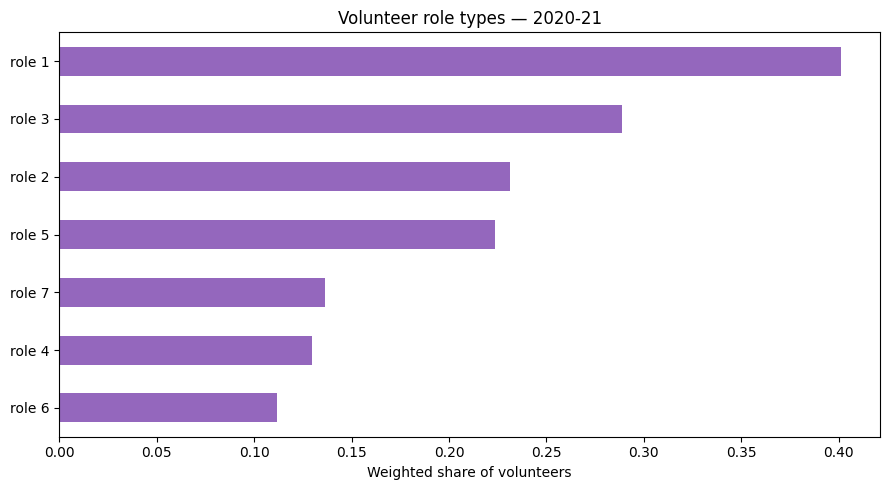

role 6    0.112
role 4    0.130
role 7    0.136
role 5    0.224
role 2    0.231
role 3    0.289
role 1    0.401


In [19]:
vols = london[london["volunteer"] == "Volunteered"].dropna(subset=["weight"]).copy()
role_share = {}
for col, label in VOL_ROLES.items():
    if col in vols.columns:
        d = vols.dropna(subset=[col])
        if len(d):
            role_share[label] = (d[col] * d["weight"]).sum() / d["weight"].sum()

if role_share:
    rs = pd.Series(role_share).sort_values()
    fig, ax = plt.subplots(figsize=(9,5))
    rs.plot(kind="barh", ax=ax, color="#9467bd")
    ax.set_xlabel("Weighted share of volunteers"); ax.set_title("Volunteer role types — 2020-21")
    plt.tight_layout(); plt.show()
    print(rs.round(3).to_string())
else:
    print("No volint*_vol role columns present — headline VolAny only.")

### Pillar 4 — volunteering rate by borough

In [20]:
vbor = weighted_share(london, ["LA_name"], "volunteer", "Volunteered").sort_values("weighted_share")
print(vbor.to_string(index=False))

               LA_name  weighted_share   n
         Tower Hamlets        0.074096 418
             Greenwich        0.083149 382
               Hackney        0.086702 363
                Camden        0.087679 395
        Waltham Forest        0.088723 404
              Hounslow        0.100151 416
             Southwark        0.104779 390
            Hillingdon        0.107948 363
             Islington        0.113298 431
               Enfield        0.114856 370
                Newham        0.115230 400
  Barking and Dagenham        0.115993 390
             Redbridge        0.117078 376
              Havering        0.117343 307
              Haringey        0.120106 354
              Lewisham        0.120469 370
           Westminster        0.122605 339
            Wandsworth        0.123157 408
                Bexley        0.123281 360
               Bromley        0.124909 340
                Harrow        0.129970 380
                Merton        0.130529 367
           

## 12. Weighted regression — drivers of being active (adjusted)

**Primary model excludes `health`.** Cramér's V between `disability` and `health` is ~0.40 in
every wave that has both (0.399 in 2018-19, 0.414 in 2022-23). Including health absorbs the
disability effect and *inverts* its coefficient (2018-19: OR 1.08 with health vs 0.64 without).
So the primary spec is age + gender + disability + ethnicity + nssec — the only specification
that runs on **every** wave and keeps disability interpretable.

A secondary model adds `health` for the health gradient alone. **Do not read the disability term
out of the secondary model.**

**Caveat:** `freq_weights` treats survey weights as frequencies, so p-values and CIs are unreliable
— read odds ratios as directional.


In [21]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ---- PRIMARY: no health (comparable across all waves) ----
m = london.dropna(subset=["activity_band","age","gender","disability",
                          "ethnicity","nssec","weight"]).copy()
m["active"] = (m["activity_band"] == "Active").astype(int)
print(f"PRIMARY complete-case sample: {len(m):,} of {len(london):,} ({len(m)/len(london):.0%})")

model = smf.glm(
    'active ~ C(age) '
    '+ C(gender, Treatment(reference="Female")) '
    '+ C(disability, Treatment(reference="No disability")) '
    '+ C(ethnicity, Treatment(reference="White British")) '
    '+ C(nssec)',
    data=m, family=sm.families.Binomial(), freq_weights=m["weight"]).fit()
print(model.summary())

PRIMARY complete-case sample: 13,109 of 16,028 (82%)
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 active   No. Observations:                13109
Model:                            GLM   Df Residuals:                 22879.39
Model Family:                Binomial   Df Model:                           18
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -14063.
Date:                Sat, 18 Jul 2026   Deviance:                       28127.
Time:                        14:06:25   Pearson chi2:                 2.29e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1100
Covariance Type:            nonrobust                                         
                                                                                     coef    std err          z      P>|z|      [0.025      0.975]
----------

In [22]:
or_table = pd.DataFrame({
    "odds_ratio": np.exp(model.params), "p_value": model.pvalues,
    "ci_low": np.exp(model.conf_int()[0]), "ci_high": np.exp(model.conf_int()[1]),
}).round(3)
print("=== PRIMARY (no health) ===")
print(or_table.to_string())

# Sanity: disability should be PROTECTIVE (OR < 1). If > 1, health has leaked in.
dis = or_table.filter(like="disability", axis=0)
print("\ndisability terms (expect OR < 1 for Limiting):")
print(dis.to_string())

# ---- SECONDARY: with health, for the health gradient ONLY ----
m2 = london.dropna(subset=["activity_band","age","gender","disability",
                           "ethnicity","nssec","health","weight"]).copy()
m2["active"] = (m2["activity_band"] == "Active").astype(int)
model2 = smf.glm(
    'active ~ C(age) '
    '+ C(gender, Treatment(reference="Female")) '
    '+ C(disability, Treatment(reference="No disability")) '
    '+ C(ethnicity, Treatment(reference="White British")) '
    '+ C(nssec) + C(health)',
    data=m2, family=sm.families.Binomial(), freq_weights=m2["weight"]).fit()
print("\n=== SECONDARY (with health) -- health gradient only, DO NOT read disability ===")
print(np.exp(model2.params).filter(like="health").round(3).to_string())

from scipy.stats import chi2_contingency
print("\nV(disability, health) =", round(cramers_v("disability","health",london), 3))

=== PRIMARY (no health) ===
                                                                                odds_ratio  p_value  ci_low  ci_high
Intercept                                                                            4.363    0.000   3.883    4.902
C(age)[T.25-34]                                                                      0.850    0.004   0.761    0.951
C(age)[T.35-44]                                                                      0.742    0.000   0.662    0.831
C(age)[T.45-54]                                                                      0.684    0.000   0.609    0.769
C(age)[T.55-64]                                                                      0.687    0.000   0.607    0.776
C(age)[T.65-74]                                                                      0.541    0.000   0.473    0.618
C(gender, Treatment(reference="Female"))[T.Male]                                     1.110    0.000   1.049    1.175
C(gender, Treatment(reference="Femal

## 13. Save cleaned data & wave comparison

In [23]:
london.to_parquet("london_2020_21_clean.parquet")
print("saved london_2020_21_clean.parquet", london.shape)
print("gss present:", "gss" in london.columns, "| non-null:", london["gss"].notna().sum())

import os
PARQUETS = {
    "2015-16": "london_2015_16_clean.parquet",
    "2016-17": "london_2016_17_clean.parquet",
    "2017-18": "london_2017_18_clean.parquet",
    "2020-21": "london_2020_21_clean.parquet",
    "2019-20": "london_2019_20_clean.parquet",
    "2020-21": "london_2020_21_clean.parquet",
    "2021-22": "london_2021_22_clean.parquet",
    "2022-23": "london_2022_23_clean.parquet",
}
rows = []
for wv, p in PARQUETS.items():
    if os.path.exists(p):
        d = pd.read_parquet(p)
        rows.append({"wave": wv, "overall_pct_active": round(weighted_share(d, [], "activity_band", "Active"), 4)})
print(pd.DataFrame(rows).to_string(index=False))

saved london_2020_21_clean.parquet (16028, 604)
gss present: True | non-null: 16028
   wave  overall_pct_active
2015-16              0.6347
2016-17              0.6228
2017-18              0.6461
2020-21              0.6240
2019-20              0.6227
2021-22              0.6427
2022-23              0.6434


## Findings — to complete after running

- **Verification:** borough map PROVEN OK; 4 codes swapped vs shared map; all LA vintages agree on GSS.
- **Overall active rate 2020-21:** ___ % — *expected ~62-64%* (England 61.4%, London ~1-2pp above).
  A dip vs 2018-19 (64.5%) is the **real pandemic effect**, not a bug.
- **Borough range:** highest ___ , lowest ___ . Expect Islington/Wandsworth high, Barking & Dagenham low.
- **Indoor vs outdoor:** ___ (38.0% subgroup). *Prior waves: indoor ~29%, outdoor ~56-57% — does the
  asymmetry replicate a third time?*
- **Volunteering:** ___ % (75.5% base — best of any wave). *2018-19 was 16.0%; expect a COVID drop.*
- **Regression (primary, no health):** disability OR ___ (must be < 1); strongest drivers ___ .
